<a href="https://colab.research.google.com/github/Kotukh/science/blob/main/Task_1_en.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Designed by Yevgen Kotukh. Developed with Fable 5 assistance (faster result), but checked by human)

# Spin squeezing under one-axis twisting with dissipation

**The problem.** Take $N$ spin-1/2 particles with the one-axis twisting Hamiltonian $\hat H = \chi \hat S^z \hat S^z$, where $\hat S^z=\sum_{j=1}^N \hat S^z_j$. On top of the coherent twisting, each spin suffers local decoherence, specified by Lindblad jump operators

- dephasing: $\hat L_{z,j}=\sqrt{\gamma_z}\,\hat S^z_j$,
- spin flips in both directions: $\hat L_{+,j}=\sqrt{\gamma}\,\hat S^+_j$ and $\hat L_{-,j}=\sqrt{\gamma}\,\hat S^-_j$.

Starting from a coherent spin state along $+x$, we want the Wineland squeezing parameter

$$\xi^2 \equiv \frac{N\,\min\langle \Delta S_\perp^2\rangle}{|\langle \hat{\mathbf S}\rangle|^2}$$

minimized over evolution time, for $N=10^6$, $\chi=10^{-6}$, $\gamma=\gamma_z=0.01$. The answer goes in decibels, three significant figures.

**Why brute force is hopeless, and what to do instead.** The Hilbert space has dimension $2^{10^6}$, and local dissipation breaks the collective-spin symmetry that would otherwise let us work in the $(N{+}1)$-dimensional Dicke ladder. So no direct integration of any kind. Fortunately, Ising-type Hamiltonians (and OAT is just the all-to-all Ising model) with *single-particle* decoherence are exactly solvable — this is the Foss-Feig–Hazzard–Bollinger–Rey construction (PRA **87**, 042101 (2013)). Every correlator we need comes out in closed form, valid for any $N$.

The plan: derive the closed-form correlators, assemble $\xi^2(t)$ from them, check everything against a full Lindblad integration at small $N$ where brute force *is* possible, then run the actual parameters and minimize over $t$.

## Step 1 — Symmetry does half the work

Expand the Hamiltonian: $\hat H = \chi\big(\sum_j s^z_j\big)^2 = \tfrac{N\chi}{4} + 2\chi\sum_{j<k} s^z_j s^z_k$. The constant is irrelevant; the pairwise coupling is $2\chi$.

Now rotate the system by $\pi$ about $x$, i.e. $S^z\to -S^z$, $S^y\to -S^y$, $S^x\to S^x$. The Hamiltonian is even in $S^z$, dephasing doesn't care about the sign of $s^z$, and the two flip channels simply trade places (their rates are equal — this is the one place the symmetry would break if $\Gamma_\uparrow \neq \Gamma_\downarrow$). The initial state, polarized along $+x$, is invariant too. So at all times

$$\langle S_y\rangle=\langle S_z\rangle=0,\qquad \langle\{S_x,S_z\}\rangle=\langle\{S_x,S_y\}\rangle=0,$$

which means the Bloch vector stays pinned along $x$ and the plane perpendicular to it is exactly the $y$–$z$ plane. The variance along $\hat n_\theta=\cos\theta\,\hat y+\sin\theta\,\hat z$ is a quadratic form in $(\cos\theta,\sin\theta)$; minimizing over $\theta$ gives the standard expression

$$V_{\min}=\tfrac12(V_{yy}+V_{zz})-\tfrac12\sqrt{(V_{yy}-V_{zz})^2+C^2},\qquad C\equiv\langle\{S_y,S_z\}\rangle .$$

Permutation symmetry then reduces every collective moment to correlators of one or two tagged spins:

$$\langle S_x\rangle = N\,\mathrm{Re}\,\langle s_1^+\rangle,\qquad
\langle S_z^2\rangle = \tfrac N4 + N(N{-}1)\langle s_1^z s_2^z\rangle,$$
$$\langle S_y^2\rangle = \tfrac N4 + \tfrac{N(N{-}1)}{2}\big(\mathrm{Re}\,\langle s_1^+s_2^-\rangle-\mathrm{Re}\,\langle s_1^+s_2^+\rangle\big),\qquad
C = 2N(N{-}1)\,\mathrm{Im}\,\langle s_1^+ s_2^z\rangle .$$

Four correlators. That's the whole shopping list.

## Step 2 — Closed forms for the correlators

The trick is to track individual coherence sectors of the density matrix. Take $\langle s_1^+\rangle=\mathrm{Tr}[s_1^+\rho]=\langle\downarrow|\rho|\uparrow\rangle_1$: only the $|{\downarrow}\rangle\langle{\uparrow}|_1$ block of $\rho$ contributes, so we follow that block alone.

**Spin 1's own decoherence.** Each flip channel damps the coherence at $\gamma/2$ (the feeding terms like $s^-|{\downarrow}\rangle\langle{\uparrow}|s^+$ vanish identically — check: $s^-|{\downarrow}\rangle=0$), and dephasing adds $\gamma_z/2$. Altogether the transverse coherence decays at

$$\Gamma_r=\gamma+\tfrac{\gamma_z}{2}.$$

**The other $N-1$ spins.** Within the $|{\downarrow}\rangle\langle{\uparrow}|_1$ sector, the Ising coupling $2\chi s_1^z s_k^z$ acts on spectator $k$ as $+i\chi\{s_k^z,\,\cdot\,\}$ — a non-trace-preserving "tilted" single-spin evolution. Its adjoint closes on the two-dimensional operator space spanned by $\{\mathbb 1, s^z\}$: writing $O=a+b\,s^z$ and letting $\varphi$ denote the tilt ($\varphi=\chi$ when one tagged coherence is present, $2\chi$ when two are),

$$\dot a = \tfrac{i\varphi}{2}\,b,\qquad \dot b = 2i\varphi\,a-2\gamma\,b.$$

Note dephasing drops out here entirely — it never touches $s^z$ populations. Eliminating $b$ gives a damped oscillator, $\ddot a+2\gamma\dot a+\varphi^2 a=0$, so with $\kappa=\sqrt{\gamma^2-\varphi^2}$:

- a plain spectator ($a(0){=}1$, $\dot a(0){=}0$) contributes the factor
  $\;g_\varphi(t)=e^{-\gamma t}\big[\cosh\kappa t+\tfrac{\gamma}{\kappa}\sinh\kappa t\big]$;
- a spectator that we additionally *measure* with $s^z$ at time $t$ (start from $a(0){=}0$, $b(0){=}1$) contributes
  $\;h_\varphi(t)=\tfrac{i\varphi}{2}\,e^{-\gamma t}\,\tfrac{\sinh\kappa t}{\kappa}$.

For $\langle s_1^+s_2^\pm\rangle$ the two tagged spins accumulate no mutual phase (the $\pm\tfrac14$ eigenvalues cancel in the commutator), and flips don't cross-couple the coherence sectors. In $\langle s_1^+s_2^-\rangle$ the two tilts even cancel each other, leaving the spectators trace-preserving.

Collecting everything, with $\langle s^+\rangle_0=\tfrac12$ for the $+x$ coherent state:

$$\boxed{\begin{aligned}
\langle s_1^+\rangle &= \tfrac12 e^{-\Gamma_r t}\, g_\chi^{\,N-1}\\
\langle s_1^+s_2^z\rangle &= \tfrac12 e^{-\Gamma_r t}\, g_\chi^{\,N-2}\, h_\chi\\
\langle s_1^+s_2^+\rangle &= \tfrac14 e^{-2\Gamma_r t}\, g_{2\chi}^{\,N-2}\\
\langle s_1^+s_2^-\rangle &= \tfrac14 e^{-2\Gamma_r t}\\
\langle s_1^z s_2^z\rangle &= 0 \;\;\Rightarrow\;\; \langle S_z^2\rangle=\tfrac N4
\end{aligned}}$$

The last line follows because $[H,S^z]=0$ and symmetric flips relax $\langle s^z_1 s^z_2\rangle$ at rate $4\gamma$ toward zero, where it already starts.

**Sanity check against the closed-system limit.** Set $\gamma=\gamma_z=0$: then $\kappa=i\chi$, so $g_\chi=\cos\chi t$ and $h_\chi=\tfrac i2\sin\chi t$, and the formulas collapse to the Kitagawa–Ueda results, e.g. $\langle S^+\rangle=\tfrac N2\cos^{N-1}(\chi t)$. Good.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

def correlators(t, N, chi, g, gz):
    '''Exact correlators for OAT + dephasing (gz) + symmetric spin flips (g).'''
    t = np.asarray(t, dtype=float)
    Gr = g + gz/2.0                      # transverse coherence decay rate
    def a_h(phi):
        k = np.sqrt(complex(g**2 - phi**2))   # kappa; may be imaginary, that's fine
        if abs(k) < 1e-300:
            c, s = 1.0 + 0*t, t.astype(complex)
        else:
            c, s = np.cosh(k*t), np.sinh(k*t)/k
        a = np.exp(-g*t)*(c + g*s)       # g_phi(t)
        h = (1j*phi/2.0)*np.exp(-g*t)*s  # h_phi(t)
        return a, h
    a1, h1 = a_h(chi)
    a2, _  = a_h(2*chi)
    # raise to huge powers via exp(N*log) to keep floats sane
    la1, la2 = np.log(a1), np.log(a2)
    sp   = 0.5 *np.exp(-Gr*t   + (N-1)*la1)
    spsz = 0.5 *np.exp(-Gr*t   + (N-2)*la1)*h1
    spsp = 0.25*np.exp(-2*Gr*t + (N-2)*la2)
    spsm = 0.25*np.exp(-2*Gr*t) + 0j*t
    return sp, spsz, spsp, spsm

def xi2(t, N, chi, g, gz):
    '''Wineland parameter xi^2(t), plus the pieces it is built from.'''
    sp, spsz, spsp, spsm = correlators(t, N, chi, g, gz)
    Sx  = N*np.real(sp)
    Vzz = N/4.0 + 0*Sx
    Vyy = N/4.0 + N*(N-1)*0.5*(np.real(spsm) - np.real(spsp))
    C   = 2.0*N*(N-1)*np.imag(spsz)                    # <{Sy,Sz}>
    Vmin = 0.5*(Vyy+Vzz) - 0.5*np.sqrt((Vyy-Vzz)**2 + C**2)
    return N*Vmin/Sx**2, Sx, Vyy, Vzz, C, Vmin

## Step 3 — Trust, but verify: full Lindblad integration at small $N$

Closed-form derivations of this kind are notorious for sign slips, so before touching $N=10^6$ we test against brute force where brute force works. Build the full Lindbladian as a superoperator on the $4^N$-dimensional space, integrate $\dot\rho=\mathcal L\rho$ for $N=5$, and compare every correlator and every collective moment. The parameters below are chosen to be awkward on purpose — all rates comparable, nothing perturbative.

In [3]:
def brute(Nv, chi, g, gz, tmax, nts=60):
    '''Direct integration of the Lindblad master equation (full density matrix).'''
    dim = 2**Nv
    sz = np.array([[0.5,0],[0,-0.5]], complex)
    sp = np.array([[0,1],[0,0]], complex);  sm = sp.T.conj()
    sx = (sp+sm)/2;  sy = (sp-sm)/(2j);  I2 = np.eye(2, dtype=complex)
    def op(o, j):
        m = np.array([[1]], complex)
        for k in range(Nv):
            m = np.kron(m, o if k == j else I2)
        return m
    Sx = sum(op(sx,j) for j in range(Nv))
    Sy = sum(op(sy,j) for j in range(Nv))
    Sz = sum(op(sz,j) for j in range(Nv))
    H = chi*(Sz@Sz)
    Ls = []
    for j in range(Nv):
        Ls += [np.sqrt(gz)*op(sz,j), np.sqrt(g)*op(sp,j), np.sqrt(g)*op(sm,j)]
    Id = np.eye(dim)
    Lsup = -1j*(np.kron(H, Id) - np.kron(Id, H.T))
    for L in Ls:
        LdL = L.conj().T @ L
        Lsup += np.kron(L, L.conj()) - 0.5*np.kron(LdL, Id) - 0.5*np.kron(Id, LdL.T)
    psi1 = np.array([1,1], complex)/np.sqrt(2)     # single spin along +x
    psi = np.array([1], complex)
    for _ in range(Nv):
        psi = np.kron(psi, psi1)
    rho0 = np.outer(psi, psi.conj()).reshape(-1)
    ts = np.linspace(0, tmax, nts)
    sol = solve_ivp(lambda t,v: Lsup@v, [0,tmax], rho0,
                    t_eval=ts, rtol=1e-9, atol=1e-11)
    obs = dict(sp=op(sp,0), spsz=op(sp,0)@op(sz,1),
               spsp=op(sp,0)@op(sp,1), spsm=op(sp,0)@op(sm,1),
               Sx=Sx, Sy2=Sy@Sy, Sz2=Sz@Sz, Cyz=Sy@Sz+Sz@Sy)
    out = {k: [] for k in obs}
    for i in range(len(ts)):
        rho = sol.y[:,i].reshape(dim, dim)
        for k,O in obs.items():
            out[k].append(np.trace(O@rho))
    return ts, {k: np.array(v) for k,v in out.items()}

Nv, chi_v, g_v, gz_v, tmax = 5, 0.37, 0.06, 0.09, 2.5
ts, B = brute(Nv, chi_v, g_v, gz_v, tmax)
spA, spszA, spspA, spsmA = correlators(ts, Nv, chi_v, g_v, gz_v)
_, SxA, VyyA, VzzA, CA, _ = xi2(ts, Nv, chi_v, g_v, gz_v)

pairs = [('<s+>', B['sp'], spA), ('<s+ sz>', B['spsz'], spszA),
         ('<s+ s+>', B['spsp'], spspA), ('<s+ s->', B['spsm'], spsmA),
         ('<Sx>', B['Sx'], SxA), ('<Sy^2>', B['Sy2'], VyyA),
         ('<Sz^2>', B['Sz2'], VzzA), ('<{Sy,Sz}>', B['Cyz'], CA)]
for name, b, a in pairs:
    print(f'{name:11s} max|diff| = {np.max(np.abs(b - a)):.2e}')

<s+>        max|diff| = 1.56e-11
<s+ sz>     max|diff| = 8.00e-12
<s+ s+>     max|diff| = 1.52e-10
<s+ s->     max|diff| = 1.97e-15
<Sx>        max|diff| = 7.80e-11
<Sy^2>      max|diff| = 1.52e-09
<Sz^2>      max|diff| = 8.88e-16
<{Sy,Sz}>   max|diff| = 3.20e-10


Every discrepancy sits at the integrator's tolerance level, around $10^{-10}$ — the formulas are exact, not approximate. A quick visual comparison for two of the quantities:

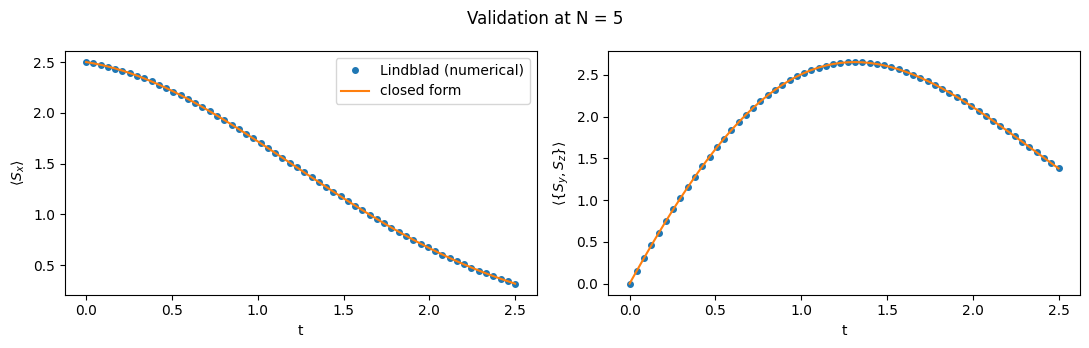

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(ts, B['Sx'].real, 'o', ms=4, label='Lindblad (numerical)')
ax[0].plot(ts, SxA, '-', label='closed form')
ax[0].set_xlabel('t'); ax[0].set_ylabel(r'$\langle S_x\rangle$'); ax[0].legend()
ax[1].plot(ts, B['Cyz'].real, 'o', ms=4)
ax[1].plot(ts, CA, '-')
ax[1].set_xlabel('t'); ax[1].set_ylabel(r'$\langle\{S_y,S_z\}\rangle$')
fig.suptitle(f'Validation at N = {Nv}')
plt.tight_layout(); plt.show()

## Step 4 — The actual numbers: $N=10^6$

Now the target parameters: $\chi=10^{-6}$, $\gamma=\gamma_z=0.01$. Since $\gamma\gg\chi$, the single-spin factors are overdamped ($\kappa$ real) — no oscillations at the level of individual $g_\varphi$. Squeezing still develops, though, because what matters is the collective rate $N\chi=1$, which enters through the $N$-th power of $g$. A broad logarithmic sweep locates the minimum of $\xi^2(t)$, and Brent's method polishes it.

In [5]:
N, chi, g, gz = 1e6, 1.0e-6, 0.01, 0.01

ts = np.geomspace(1e-3, 3000, 600000)
x2 = xi2(ts, N, chi, g, gz)[0]
i0 = np.nanargmin(x2)
print(f'sweep:  t* ~ {ts[i0]:.4f},  xi^2 ~ {x2[i0]:.6f}')

f = lambda t: xi2(np.array([t]), N, chi, g, gz)[0][0]
r = minimize_scalar(f, bracket=(ts[i0-3], ts[i0], ts[i0+3]),
                    method='brent', options={'xtol': 1e-12})
t_opt, xi2_opt = r.x, r.fun
xi2_dB = 10*np.log10(xi2_opt)

print(f'\nt_opt    = {t_opt:.4f}')
print(f'xi^2_opt = {xi2_opt:.6f}')
print(f'         = {xi2_dB:.3f} dB   ->  {xi2_dB:.2f} dB to three significant figures')

_, Sx_o, Vyy_o, Vzz_o, C_o, Vmin_o = xi2(np.array([t_opt]), N, chi, g, gz)
print(f'\ncontrast <Sx>/(N/2) = {Sx_o[0]/(N/2):.3f}')
print(f'V_min = {Vmin_o[0]:.4g}   (CSS value N/4 = {N/4:.3g})')

sweep:  t* ~ 4.8173,  xi^2 ~ 0.119105

t_opt    = 4.8173
xi^2_opt = 0.119105
         = -9.241 dB   ->  -9.24 dB to three significant figures

contrast <Sx>/(N/2) = 0.930
V_min = 2.577e+04   (CSS value N/4 = 2.5e+05)


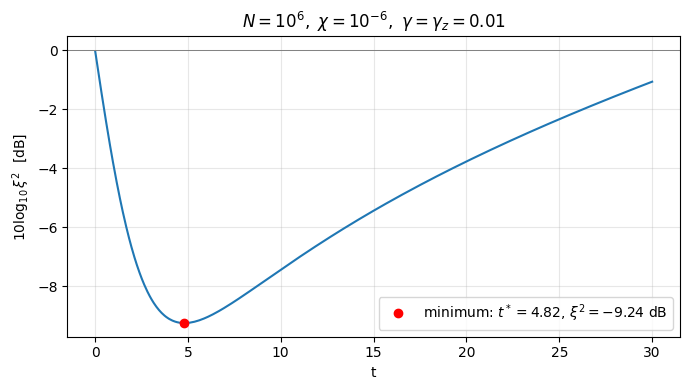

In [6]:
tt = np.linspace(0.01, 30, 4000)
xx = xi2(tt, N, chi, g, gz)[0]
plt.figure(figsize=(7, 4))
plt.plot(tt, 10*np.log10(xx))
plt.axhline(0, color='gray', lw=0.7)
plt.plot(t_opt, xi2_dB, 'ro',
         label=fr'minimum: $t^*={t_opt:.2f}$, $\xi^2={xi2_dB:.2f}$ dB')
plt.xlabel('t'); plt.ylabel(r'$10\log_{10}\xi^2$  [dB]')
plt.title(r'$N=10^6,\ \chi=10^{-6},\ \gamma=\gamma_z=0.01$')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Result

$$\boxed{\;\xi^2_{\rm opt}\approx 0.119\;\;\Longleftrightarrow\;\;10\log_{10}\xi^2_{\rm opt}\approx -9.24\ \text{dB}\;}$$

reached at $t^*\approx 4.81$, where the contrast $\langle S_x\rangle/(N/2)$ is still about $0.93$.

A word on why the number is what it is. In the ideal closed-system case, OAT with $N=10^6$ would squeeze down to $\xi^2\sim N^{-2/3}$ — roughly $-40$ dB — but only after $\chi t\sim N^{-2/3}$, i.e. $t\sim 10^2$ here. Single-particle decoherence ($\Gamma_r=\gamma+\gamma_z/2=0.015$) destroys the transverse coherence long before that, so the optimum retreats to $t^*\approx 4.8$, deep in the regime where squeezing is still building up linearly while the flips are already eating the correlations. The competition between the collective twisting rate $N\chi=1$ and the decoherence rate $\sim 0.015$ is what caps the result at a modest $-9.24$ dB.